# **MARKETING CAMPAIGN ANALYSIS**
This project focused on analyzing a dataset containing information about customers and their responses to 5 marketing campaign

The dataset is downloaded from https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign

# **Importing csv file to Colab and necessary libraries**

In [ ]:
import pandas as pd

# Loading dataset which is in csv format
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('marketing_campaign.csv')
df.head()



Saving marketing_campaign.csv to marketing_campaign (8).csv


,ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response
0,5524;1957;Graduation;Single;58138;0;0;2012-09-...
1,2174;1954;Graduation;Single;46344;1;1;2014-03-...
2,4141;1965;Graduation;Together;71613;0;0;2013-0...
3,6182;1984;Graduation;Together;26646;1;0;2014-0...
4,5324;1981;PhD;Married;58293;1;0;2014-01-19;94;...


**DATA PREPROCESSING**

The df.info() function is used to check the structure of the dataset. It shows the column names, data types (such as integer, float, or object), and the number of non-null values in each column. This helps identify missing values and potential data type issues.

The df.head() function displays the first few rows of the dataset. It gives a quick look at the actual data values, which helps in understanding what kind of information each column contains.

In [ ]:
# Checking structure of your data
df.info()

# See first few rows again
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                                                                                                    --------------  ----- 
 0   ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeat

,ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response
0,5524;1957;Graduation;Single;58138;0;0;2012-09-...
1,2174;1954;Graduation;Single;46344;1;1;2014-03-...
2,4141;1965;Graduation;Together;71613;0;0;2013-0...
3,6182;1984;Graduation;Together;26646;1;0;2014-0...
4,5324;1981;PhD;Married;58293;1;0;2014-01-19;94;...


# **Checking for missing values**

The df.isnull().sum() function checks each column in the dataset for missing (null or NaN) values.

It returns the total number of missing values per column, helping identify which columns need to be cleaned or imputed.



In [ ]:
# Checking of missing values
df.isnull().sum()

,0
ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response,0


# **Checking for missing values (with Custom nulls)**

While loading the dataset, we define additional strings like " ", "", "NA", and "null" as missing values using the na_values parameter.

This ensures that cells containing these placeholders are treated as actual missing values (NaN).

The df.isnull().sum() function then counts and displays the number of missing values in each column, which helps in identifying which features need cleaning.

In [ ]:
# Checking of missing values ,
# Considering null cell as missing
df = pd.read_csv("marketing_campaign.csv", sep=";", na_values=[" ", "", "NA", "null"])
df.isnull().sum()


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# **Checking outliers**

We have got 24 missing values in "Income" column.
In order to treat this missing values we have to replace it either with mean or median.

We are first checking for outliers in income column because it skews the mean income.

Since we have missing values in the dataset, it's useful to check for outliers before deciding how to handle them.

We use a boxplot to visually detect outliers in the Income column.

The boxplot helps identify values that are significantly higher or lower than the rest of the data (shown as points outside the box).

This helps in deciding whether to keep, remove, or treat these extreme values differently.



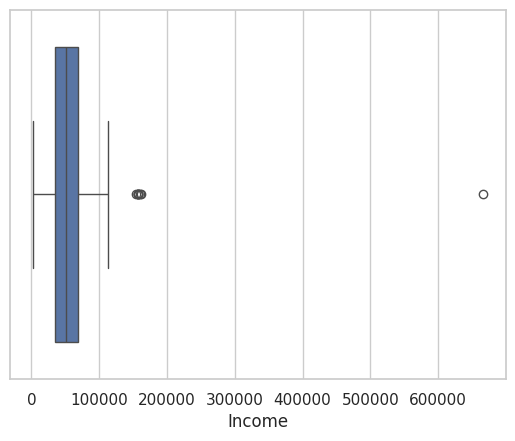

In [ ]:
# Our data has missing values so we checking for outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Income'])
plt.show()


The income column has some outliers which is detected by IQR method. So we are not removing outliers rows as it can remove necessary insights instead we are using mean value to resplace missing cells.

the income column had some missing values which can affect analysis.

instead of removing those rows, we replace the missing values with the median income.

using median is better than mean in this case because it is less affected by outliers.



In [ ]:
#Replacing missing values with median
median_income = df['Income'].median()
df['Income'] = df['Income'].fillna(median_income)





We are checking the missing values again to check it get replaced or not.

The following code now shows that income column has zero missing values.

In [ ]:
#checking missing values again
df['Income'].isnull().sum()




np.int64(0)

# **Checking outliers in other columns**
Checking of outliers in other columns like  'Age',
    'Total_Spent',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases',
    'NumWebVisitsMonth' using IQR method

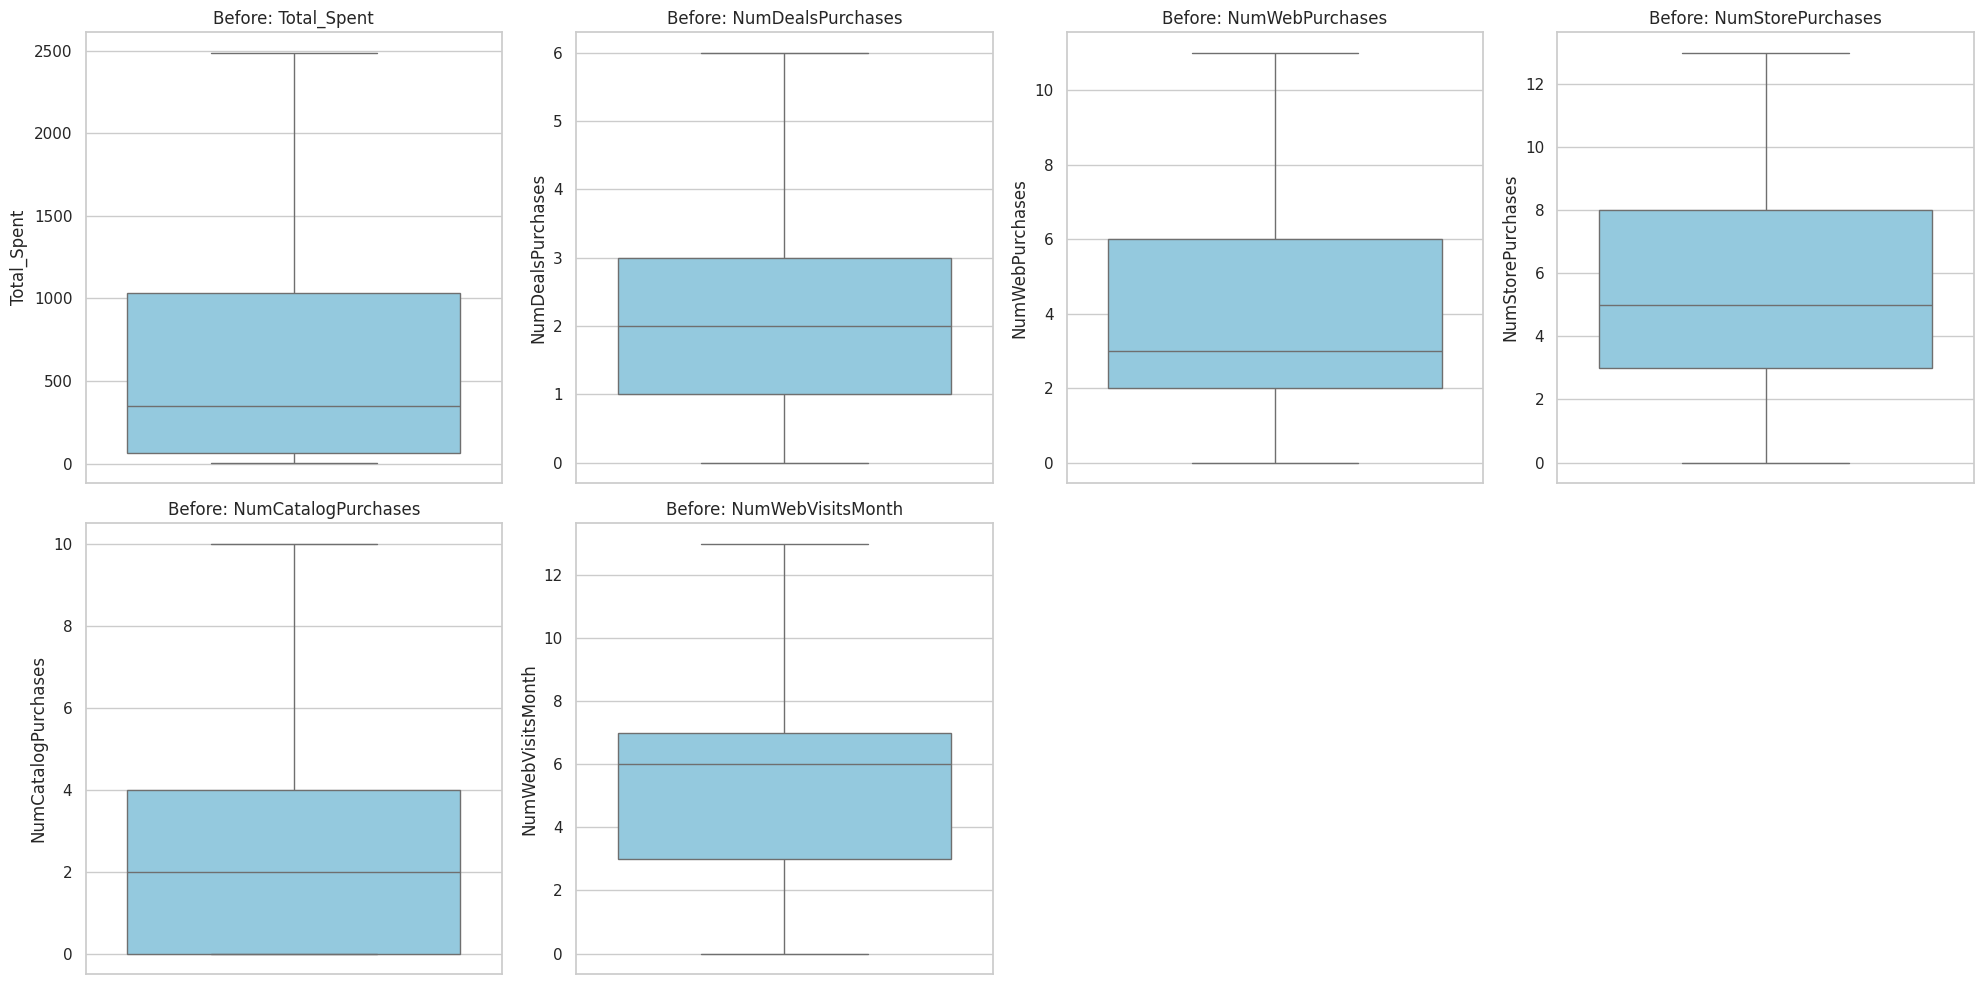

In [180]:
columns_to_check = [
    'Total_Spent',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases',
    'NumWebVisitsMonth'
]
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy for visualizing before removal
df_before = df.copy()

# Boxplots before outlier removal
plt.figure(figsize=(20, 10))
for i, col in enumerate(columns_to_check):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df_before[col], color='skyblue')
    plt.title(f'Before: {col}')
plt.tight_layout()
plt.show()


# **Removal of outliers**
We are removing outliers in the data by finding it by IQR method

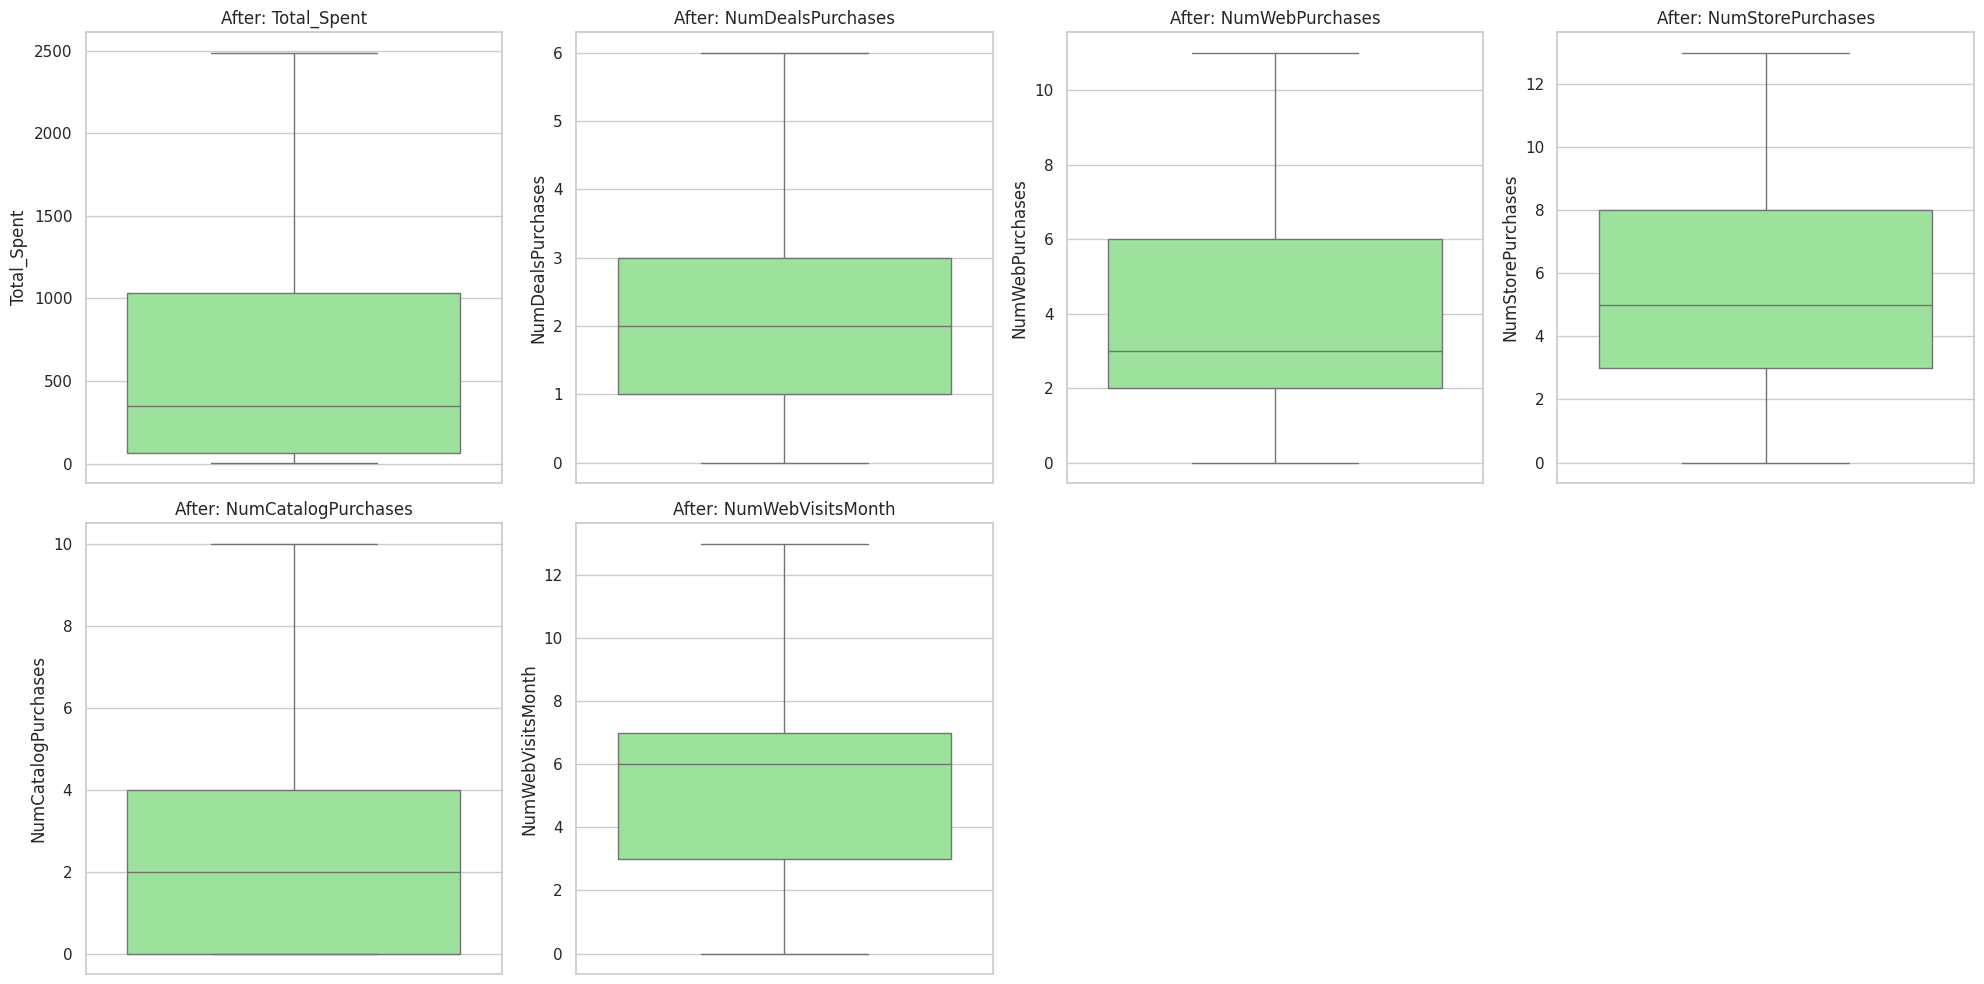

In [178]:
# Function to remove outliers using IQR
def remove_outliers_iqr(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data

# Apply removal
df = remove_outliers_iqr(df, columns_to_check)
# Boxplots after outlier removal
plt.figure(figsize=(20, 10))
for i, col in enumerate(columns_to_check):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'After: {col}')
plt.tight_layout()
plt.show()

# **Handling Duplicate Rows in the Dataset**

The code first identifies the number of duplicate rows present in the DataFrame df using the duplicated() method, which marks all duplicate entries except for the first occurrence. The sum() function then counts how many duplicates exist. This helps quantify the extent of data redundancy.

Next, the code removes all duplicate rows by applying the drop_duplicates() method, which keeps only the first occurrence of each duplicate and eliminates the rest. This operation ensures the dataset is cleaned from repeated entries that could bias the analysis or model training.

Finally, the updated shape of the DataFrame is printed to confirm the reduction in the number of rows after duplicates are removed.

In [ ]:
# Check number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicate rows
df = df.drop_duplicates()
print(f"New shape after removing duplicates: {df.shape}")


Number of duplicate rows: 0
New shape after removing duplicates: (2240, 29)


# **Converting data types into appropriate form**

we are checking data type of each column to check weather it is correct type or not

In [ ]:
# Check data types
print(df.dtypes)


ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


**Converting column into appropriate data type**

The Dt_Customer column is converted from a string/object type to a datetime format to enable proper date-based operations and analysis. The errors='coerce' argument ensures that invalid date entries are set to NaT (missing).

Several columns representing categorical data (such as education level, marital status, complaint status, campaign responses) are explicitly converted to the category datatype. This optimizes memory usage and improves performance for categorical operations like grouping or encoding.

In [ ]:
# Convert 'Dt_Customer' to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

# Convert these columns to categorical
categorical_cols = [
    'Education',
    'Marital_Status',
    'Complain',
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

Checking again to confirm the data type of column.

We have successfully changed some of the data types of columns into appropriate form.

In [ ]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,category
Marital_Status,category
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64


# **Removing duplicate values**

df.duplicated().sum() counts how many rows are exact duplicates of previous rows.

df.drop_duplicates() removes these duplicate rows, ensuring each row is unique in the dataset.



In [ ]:
#Removing duplicates

# Check number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicate rows
df = df.drop_duplicates()
print(f"New shape after removing duplicates: {df.shape}")



Number of duplicate rows: 0
New shape after removing duplicates: (2240, 1)


# **Exploratory Data Analysis**

We have finally cleaned the data and now begins Exploratory Data Analysis.

EDA is a crucial step in understanding your dataset by summarizing its main characteristics, often with visual methods. It helps to get a basic understanding of the data, its distribution, and relationships between variables

**Descriptive Statistics**

Get a summary of the numerical columns, including count, mean, standard deviation, min, max, and quartiles.

In [ ]:
# Descriptive statistics for numerical columns
print(df.describe())

       ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response
count                                                2240                                                                                                                                                                                                                                                                                                                      
unique                                               2240                                                                                                                                                                                                               

# **Analyzing Categorical Data**

This section analyzes the distribution of values in several categorical columns like 'Education', 'Marital_Status', and campaign response columns

The code defines a list of categorical_cols. It then attempts to load the data (with error handling). Finally, it loops through the list and uses .value_counts() for each column to count how many times each unique category appears. This helps understand the composition of the dataset for these key attributes.

In [ ]:
# Value counts for categorical columns
categorical_cols = [
    'Education',
    'Marital_Status',
    'Complain',
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'
]

try:
    df = pd.read_csv("marketing_campaign.csv", sep=";")
except FileNotFoundError:
    print("Error: 'marketing_campaign.csv' not found. Please ensure the file is in the correct directory.")


for col in categorical_cols:
    # Check if the column exists before trying to access it
    if col in df.columns:
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts())
    else:
        print(f"\nColumn '{col}' not found in the DataFrame.")


Value counts for 'Education':
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Value counts for 'Marital_Status':
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Value counts for 'Complain':
Complain
0    2219
1      21
Name: count, dtype: int64

Value counts for 'Response':
Response
0    1906
1     334
Name: count, dtype: int64

Value counts for 'AcceptedCmp1':
AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64

Value counts for 'AcceptedCmp2':
AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64

Value counts for 'AcceptedCmp3':
AcceptedCmp3
0    2077
1     163
Name: count, dtype: int64

Value counts for 'AcceptedCmp4':
AcceptedCmp4
0    2073
1     167
Name: count, dtype: int64

Value counts for 'AcceptedCmp5':
AcceptedCmp5
0    2077
1     163
Name: count, dtype: int6

In [ ]:
# Value counts for categorical columns
categorical_cols = [
    'Education',
    'Marital_Status',
    'Complain',
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'
]

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())


Value counts for 'Education':
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Value counts for 'Marital_Status':
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Value counts for 'Complain':
Complain
0    2219
1      21
Name: count, dtype: int64

Value counts for 'Response':
Response
0    1906
1     334
Name: count, dtype: int64

Value counts for 'AcceptedCmp1':
AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64

Value counts for 'AcceptedCmp2':
AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64

Value counts for 'AcceptedCmp3':
AcceptedCmp3
0    2077
1     163
Name: count, dtype: int64

Value counts for 'AcceptedCmp4':
AcceptedCmp4
0    2073
1     167
Name: count, dtype: int64

Value counts for 'AcceptedCmp5':
AcceptedCmp5
0    2077
1     163
Name: count, dtype: int6

# **Visualize Numerical Data Distributions**

This section visualizes the distribution of your numerical columns using histograms, which are useful for seeing how often different values appear in your data.

The code first identifies numerical columns (integers and floats) in your dataset, storing their names. It also creates a list of columns to ignore, such as 'ID', because their distribution isn't typically informative.

It then loops through the identified numerical columns. For each column not in the exclusion list, it creates a new plot. Inside the loop, it generates a histogram of the column's data using seaborn. A smooth line representing the estimated density of the data is added to the histogram.

Titles and axis labels are added to each plot to clearly show which column's distribution is being displayed and what the axes represent. Finally, each plot is shown. This process repeats for every relevant numerical column, providing visual summaries of their distributions.

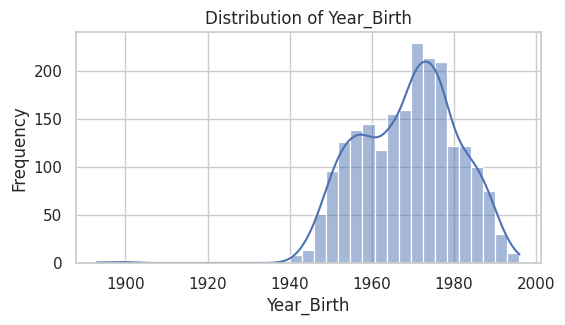

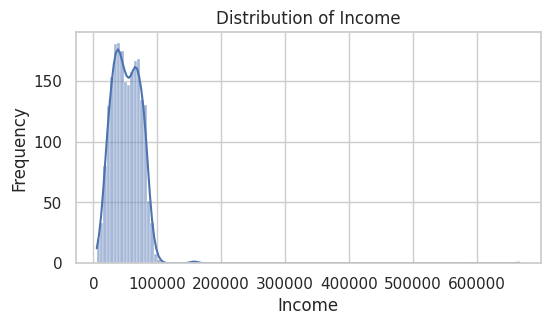

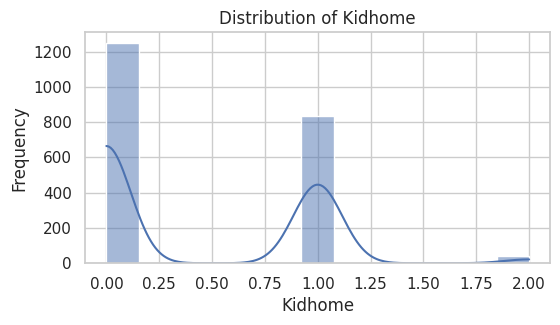

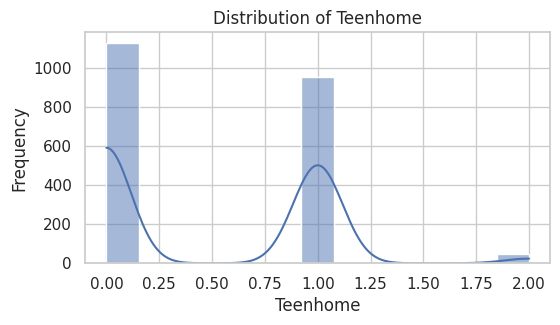

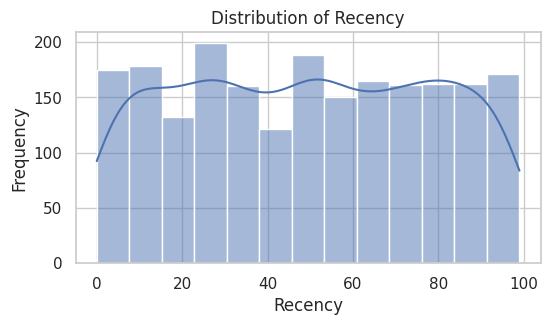

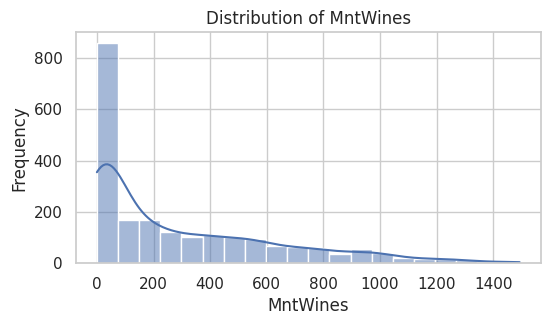

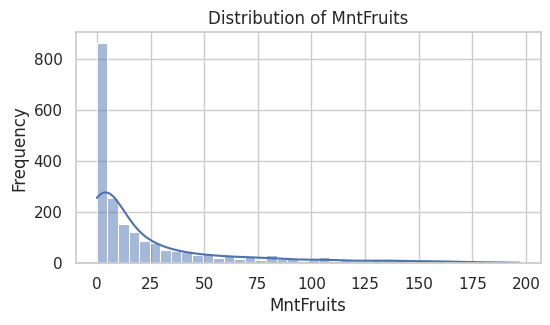

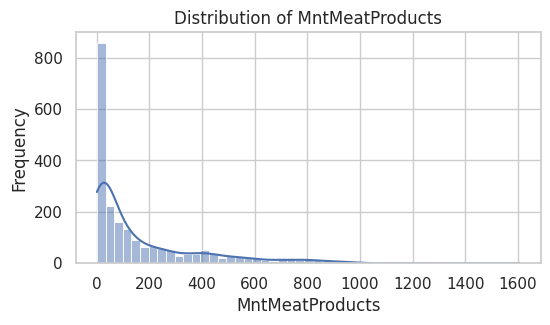

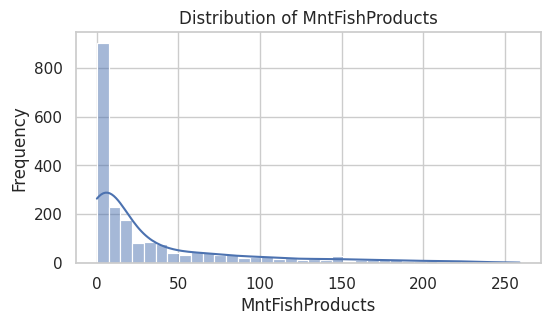

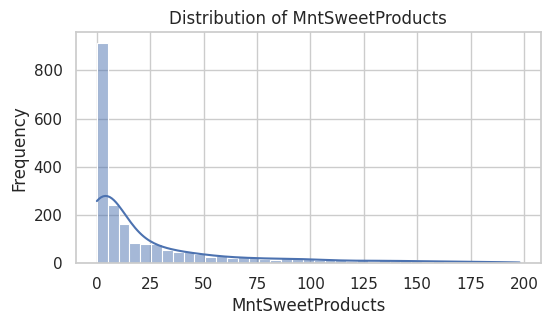

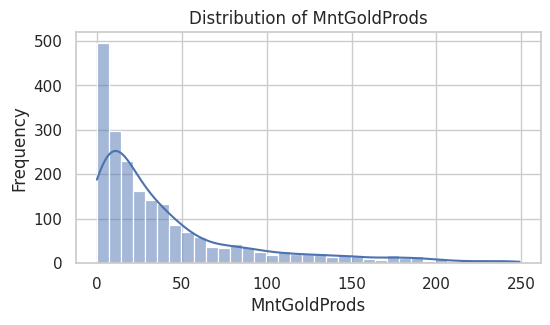

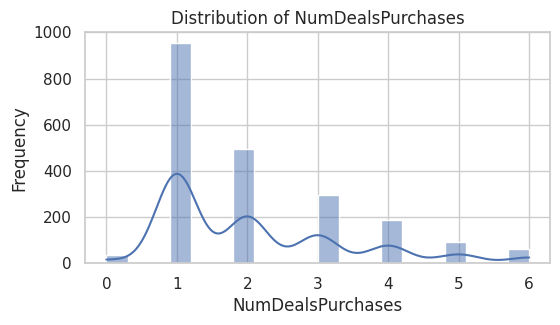

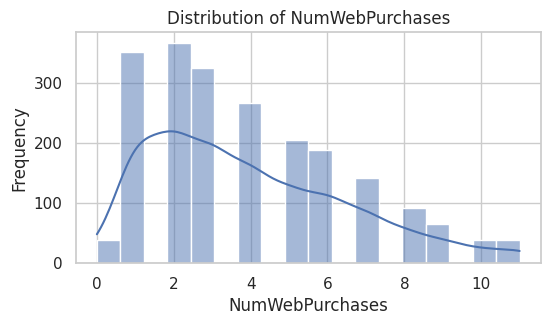

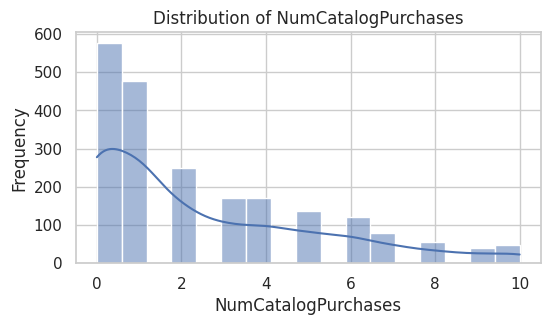

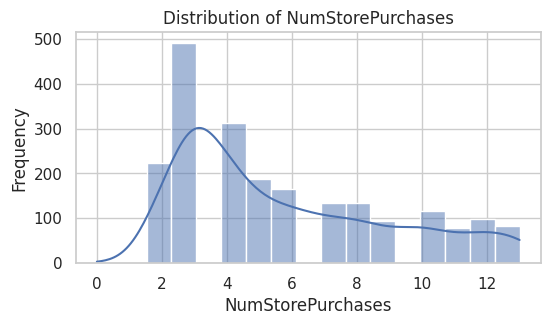

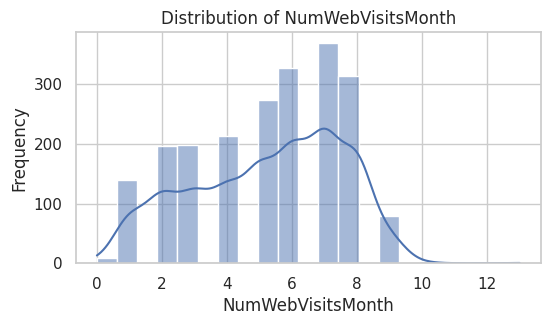

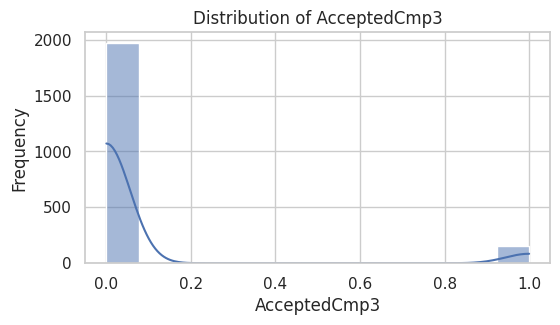

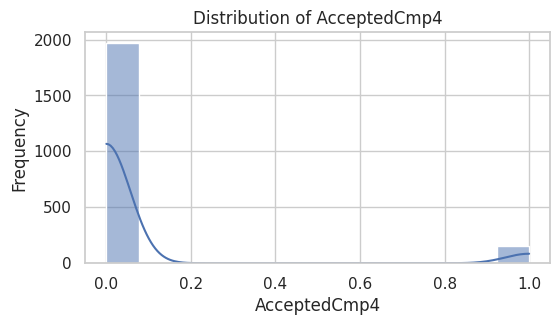

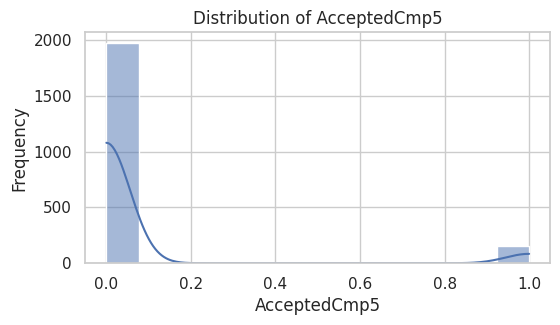

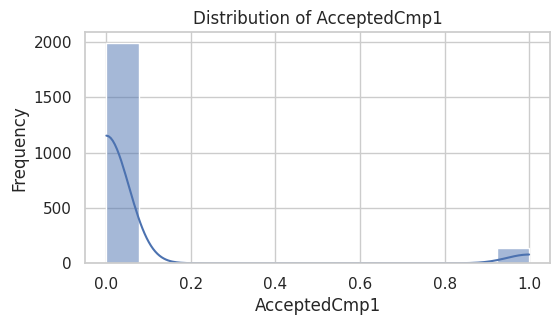

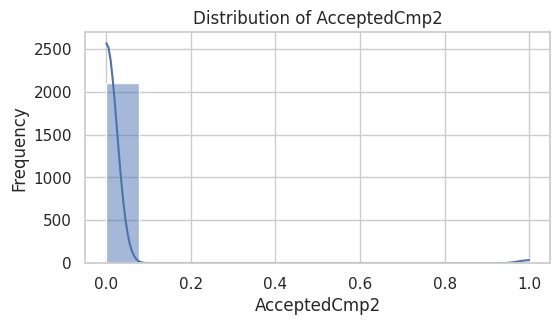

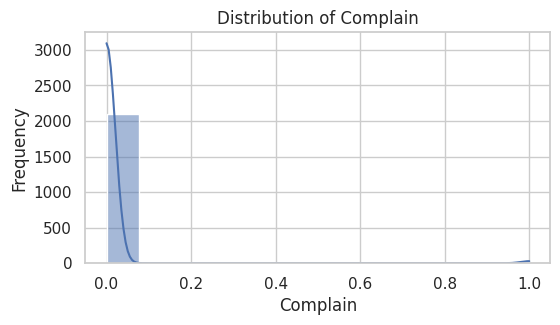

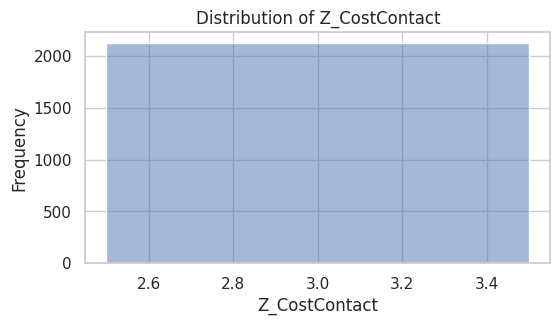

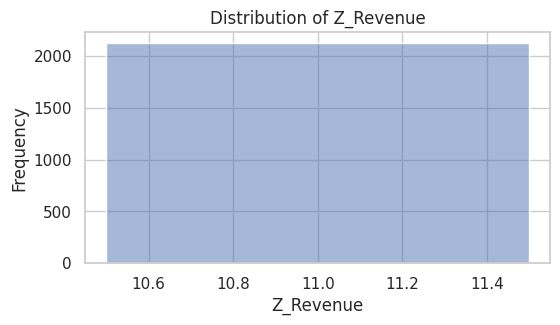

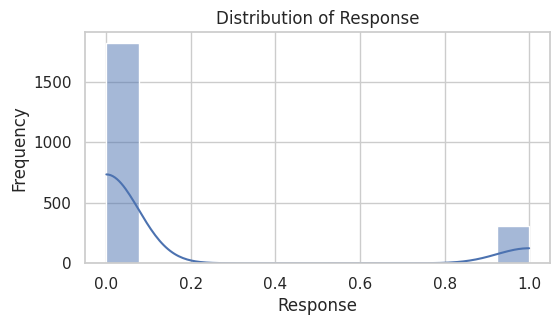

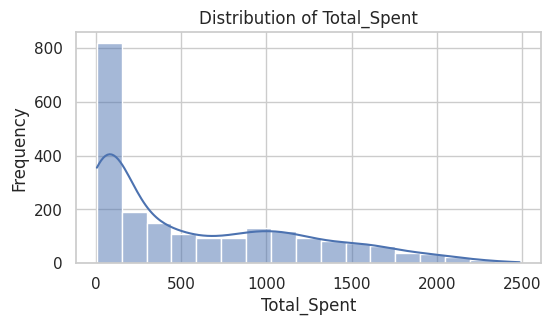

In [183]:
# Histograms for numerical columns (excluding ID and date)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['ID'] # Add other columns to exclude if needed

for col in numerical_cols:
    if col not in exclude_cols:
        plt.figure(figsize=(6, 3))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# **Countplots for Categorical Columns**

The code starts by defining a list called categorical_cols which holds the names of the columns intended for visualization, such as 'Education', 'Marital_Status', and the campaign acceptance columns.

It then iterates through each column name in this list. For each column, a new plot is created with a specific size. A countplot is generated using seaborn.countplot(), which automatically calculates and displays the number of occurrences for each unique category in the current column on the x-axis.

Titles and axis labels are added to make the plot clear: the title indicates "Count of [Column Name]", the x-axis shows the column name, and the y-axis represents the count. To improve readability, especially if category names are long, the x-axis labels are rotated by 45 degrees. Finally, each plot is displayed. This loop ensures that a separate countplot is generated and shown for each categorical column listed, providing a visual summary of their distributions.

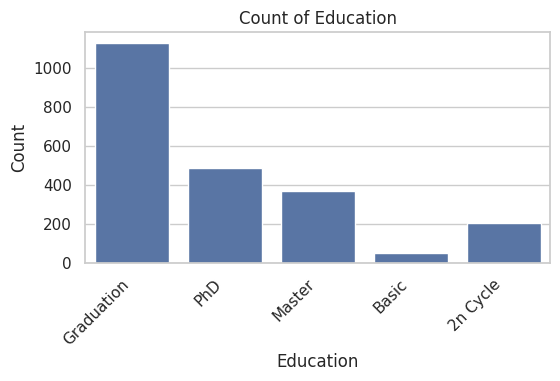

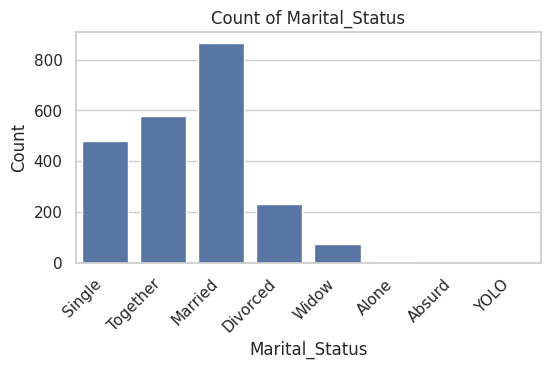

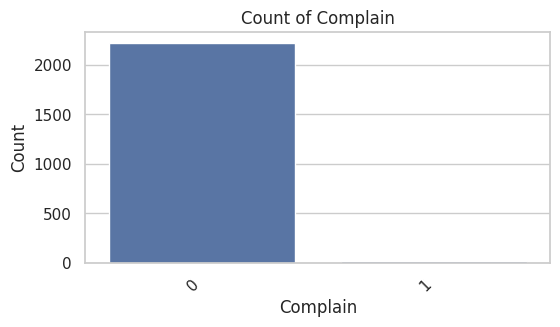

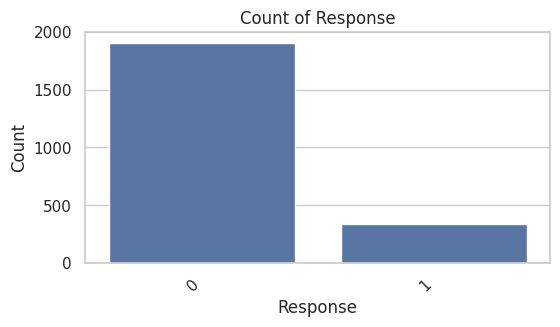

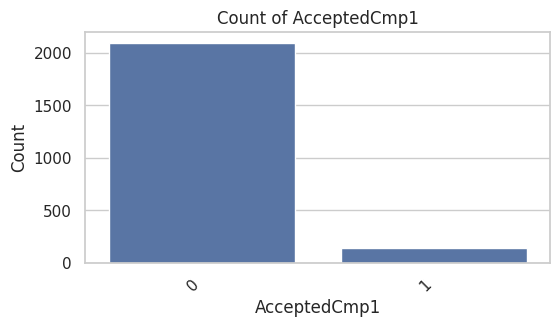

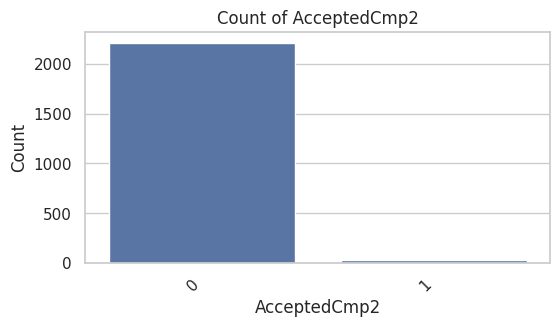

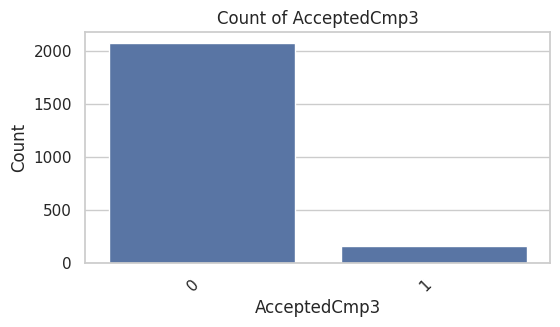

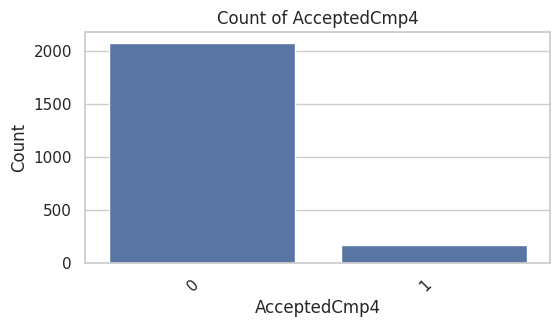

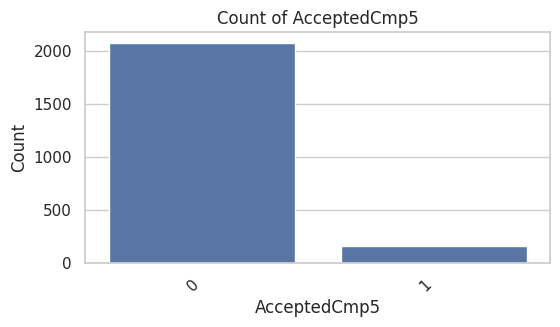

In [167]:
# Countplots for categorical columns
categorical_cols = [
    'Education',
    'Marital_Status',
    'Complain',
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'
]

for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# **Correlation Heatmap**

plt.figure(figsize=(12, 8)) creates a new figure for the plot and sets its size.
df.select_dtypes(include=['int64', 'float64']) selects only the numerical columns from your DataFrame df.
.corr() calculates the pairwise correlation of all the selected numerical columns.
sns.heatmap(...) generates the heatmap visualization using the calculated correlation matrix.
annot=True displays the correlation values on each cell.
cmap='coolwarm' sets the color scheme for the heatmap.
fmt=".2f" formats the displayed correlation values.
plt.title('Correlation Heatmap') sets the title of the plot.
plt.show() displays the generated heatmap.

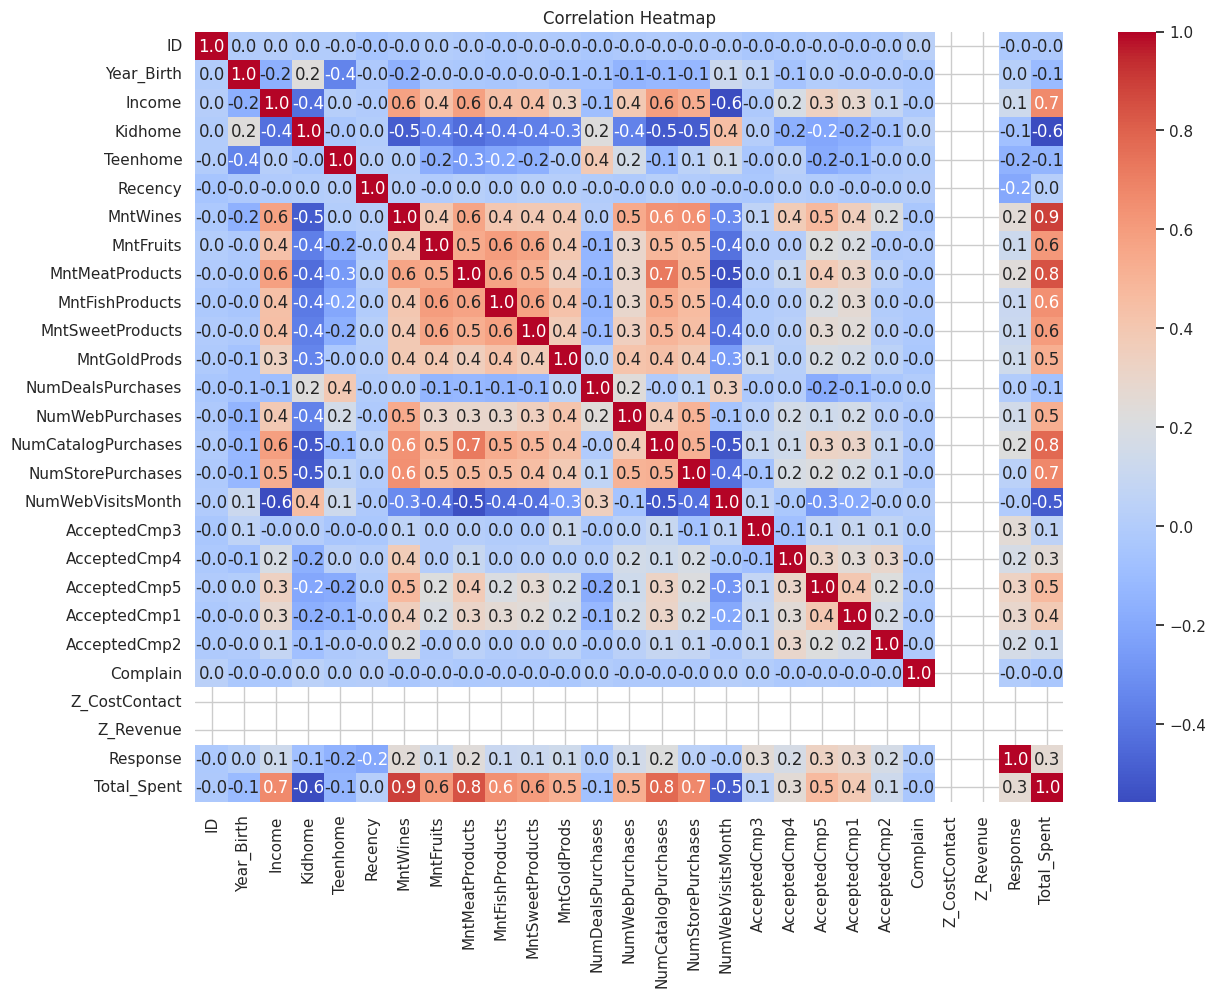

In [ ]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".1f")
plt.title('Correlation Heatmap')
plt.show()

# **Visualize Income Distribution**

This part generates a histogram to show how the values in the Income column are distributed across different ranges. A smooth line is also added to show the estimated density of the data.

Visualize Marital Status Distribution
This section creates a countplot. It counts how many times each unique value appears in the Marital_Status column and displays this count as bars. The labels on the x-axis are rotated for better readability.

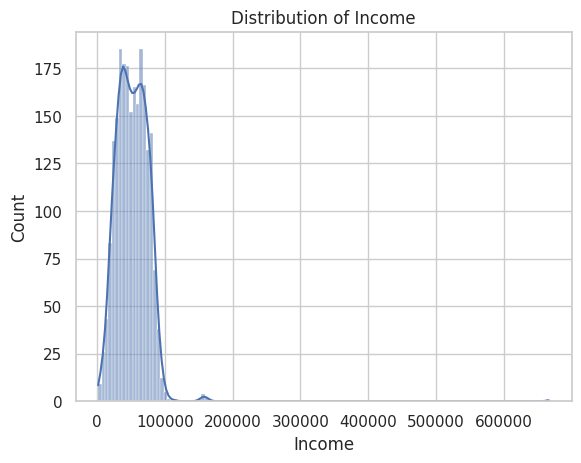

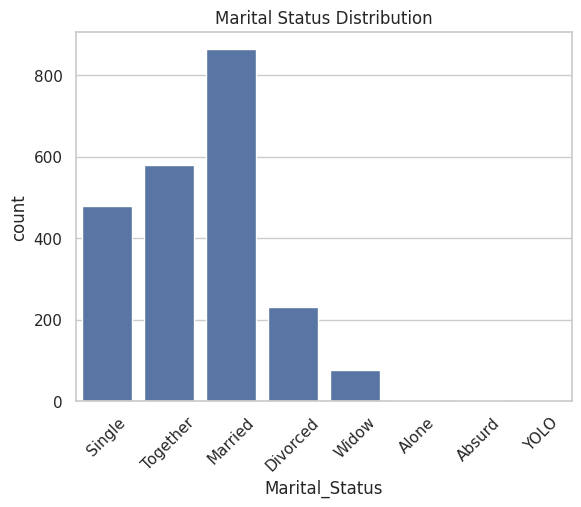

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of Income
sns.histplot(df['Income'], kde=True)
plt.title("Distribution of Income")
plt.show()

# Countplot for categorical variable
sns.countplot(x='Marital_Status', data=df)
plt.xticks(rotation=45)
plt.title("Marital Status Distribution")
plt.show()


# **Income vs. Response**

This code visualizes the distribution of customer income based on whether they responded to the marketing campaign using a boxplot. This helps in understanding if there's a difference in income levels between responders and non-responders.

# **Education vs. Response**

This code creates a countplot to show the relationship between customers' education levels and their response to the campaign. It groups customers by their education and then further by their response status, allowing you to see the count of responders and non-responders within each education category. The x-axis labels are rotated for better readability.

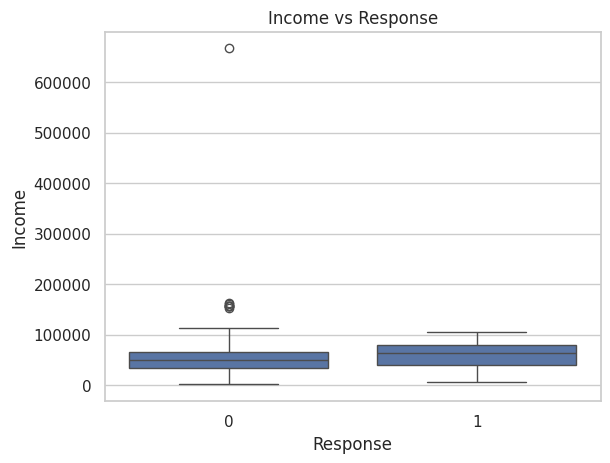

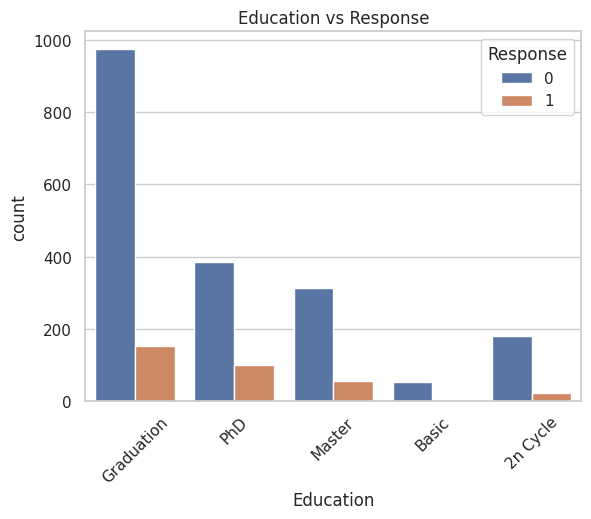

In [ ]:
# Income vs Response
sns.boxplot(x='Response', y='Income', data=df)
plt.title("Income vs Response")
plt.show()

# Education vs Response
sns.countplot(x='Education', hue='Response', data=df)
plt.xticks(rotation=45)
plt.title("Education vs Response")
plt.show()



# **Loading Data and Preparing for Analysis**

This section of the code reloads the dataset and prepares it for analysis by handling potential missing values and extracting a new feature.

The code first reads the "marketing_campaign.csv" file, specifying that the data is separated by semicolons and treating several string variations like " ", "", "NA", and "null" as missing values.

Next, it converts the Dt_Customer column into a datetime format, which allows for date-based operations. Any values that cannot be converted into a valid date will be marked as missing.

From the converted Dt_Customer column, a new column called Year_Joined is created by extracting only the year from each customer's joining date.

Finally, a countplot is generated to visualize how many customers joined in each year, providing insight into the company's customer acquisition over time

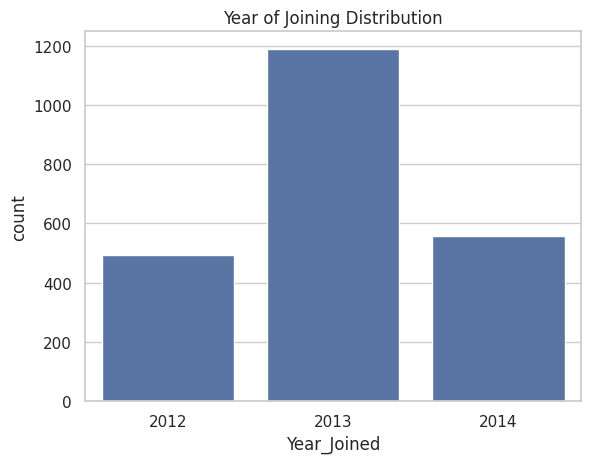

In [ ]:
# Re-read the data with custom nulls if needed, or ensure the last read operation is used
df = pd.read_csv("marketing_campaign.csv", sep=";", na_values=[" ", "", "NA", "null"])

# Convert 'Dt_Customer' to datetime AFTER the last data load
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

# Now you can safely extract the year
df['Year_Joined'] = df['Dt_Customer'].dt.year

sns.countplot(x='Year_Joined', data=df)
plt.title("Year of Joining Distribution")
plt.show()

# Final Exploratory Data Analysis Steps

This section of the code performs several key steps in the final phase of Exploratory Data Analysis (EDA) to further understand the dataset.

**Step 1: Check Unique Values in Categorical Columns**

This step examines the unique categories and their counts within specific categorical columns: 'Education' and 'Marital_Status'. The value_counts() function is used to count the occurrences of each category, and the results are printed to the console.

**Step 2: Visualize Categorical Data**

This step creates visualizations (countplots) to show the distribution of values in the 'Education' and 'Marital_Status' columns. A countplot is generated for each column, displaying the number of occurrences for each unique category as bars.

**Step 3: Visualize Numerical Data**

This step visualizes the distribution of selected numerical columns using a histogram and a boxplot. A histogram with a Kernel Density Estimate line is created for the 'Income' column to show its distribution. A boxplot is generated for spending on products ('MntWines', 'MntFruits', 'MntMeatProducts') to summarize their distributions and identify potential outliers.

**Step 4: Total Spending Feature**

This step creates a new feature called Total_Spent by summing up the spending across several product categories: 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', and 'MntGoldProds'. This new column is added to the DataFrame.

**Step 5: Spending vs Income**

This step visualizes the relationship between customer income and their total spending using a scatter plot. The plot shows individual customers as points, with their income on the x-axis and total spending on the y-axis, to observe any potential correlation.

**Step 6: Recency vs Response**

This step uses a boxplot to compare the 'Recency' of customers based on whether they responded to the marketing campaign ('Response'). The boxplot shows the distribution of 'Recency' values for customers who responded versus those who did not, helping to identify differences between the two groups.

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


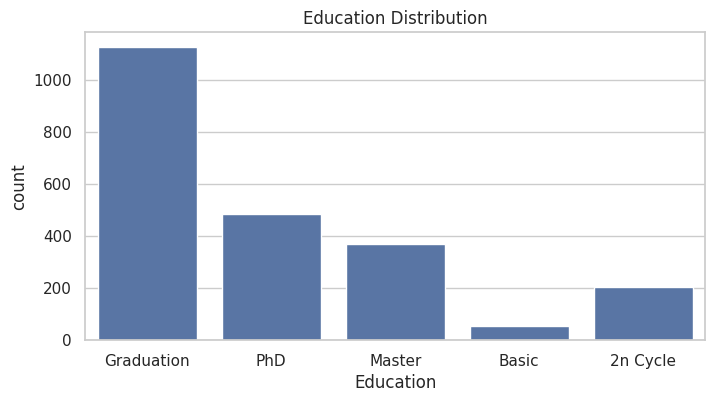

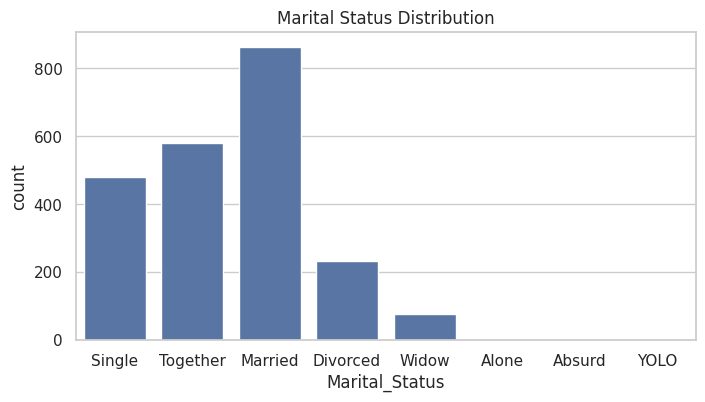

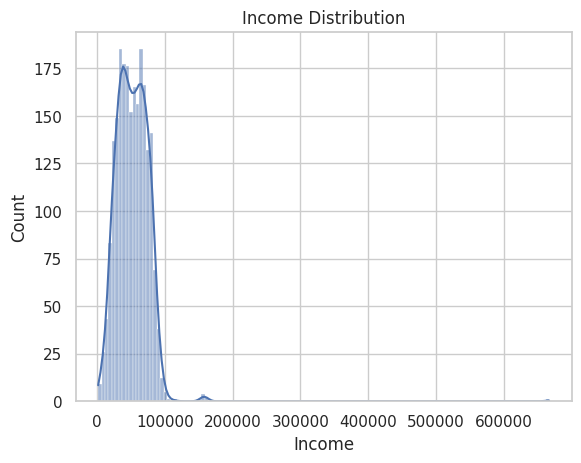

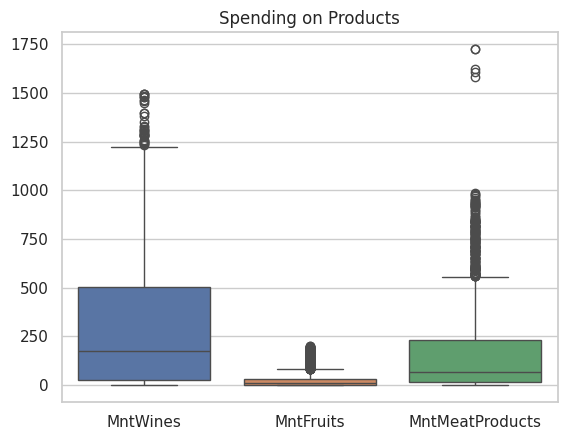

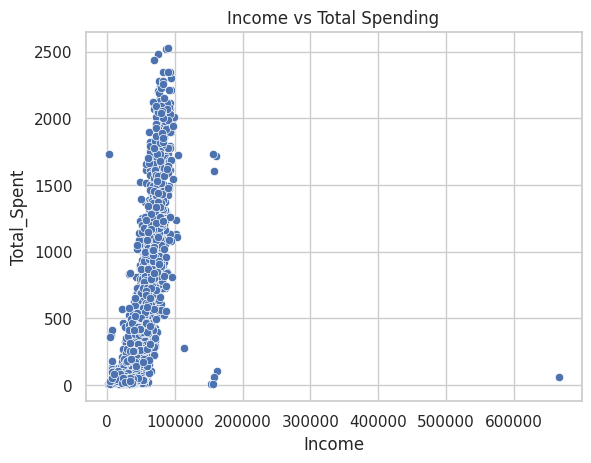

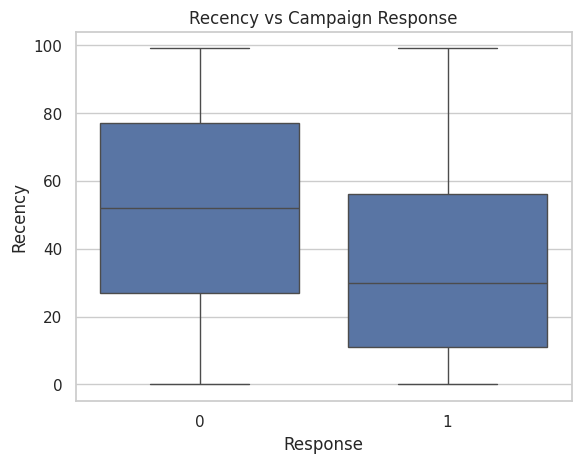

In [165]:

# Step 1: Check unique values in categorical columns
print(df['Education'].value_counts())
print(df['Marital_Status'].value_counts())

# Step 2: Visualize Categorical Data
plt.figure(figsize=(8, 4))
sns.countplot(x='Education', data=df)
plt.title('Education Distribution')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='Marital_Status', data=df)
plt.title('Marital Status Distribution')
plt.show()

# Step 3: Visualize Numerical Data
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.show()

sns.boxplot(data=df[['MntWines', 'MntFruits', 'MntMeatProducts']])
plt.title('Spending on Products')
plt.show()

# Step 4: Total Spending Feature
df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

# Step 5: Spending vs Income
sns.scatterplot(data=df, x='Income', y='Total_Spent')
plt.title('Income vs Total Spending')
plt.show()

# Step 6: Recency vs Response
sns.boxplot(x='Response', y='Recency', data=df)
plt.title('Recency vs Campaign Response')
plt.show()

# **Feature Analysis: Campaign Features**



**Insight #1: **
The 3rd campaign indicates a poor amount of spending and only low-income customers have any interest in joining it



**Insight #2:**

- In this case, the number of people who participated in 2nd campaign is the lowest (but the previous graph indicates that it still generates more spending compared with other campaigns)
- People who are already married have more tendency of joining the marketing campaign


**Insight #3:**
- People who don’t have any children tend to join the campaign
- In 3rd campaign, the people that have children have more interest compared with other campaigns



**Insight #4:**
- The majority of people who joined all campaigns have the educational status of undergraduate degree
- The 3rd campaign is the only campaign that’s affordable to people who have the educational status of highschool graduate


**Insight #5:**
- The majority of people who joined all campaigns tend to purchase the item by visiting the store directly
Feature Analysis: Demography Features



**Insight #6:**
- There’s no significant difference of income or spending between people who’re married or not
